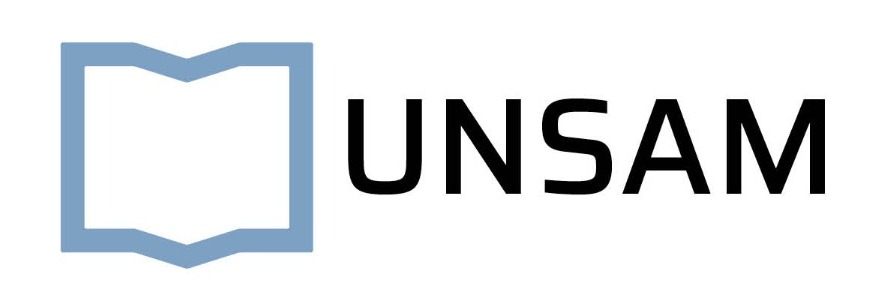

#### Análisis y Procesamiento de Señales

# TS0: Primeros pasos en la simulación
#### Alumno: Sebastián Roca Garza



# Introducción
**Este trabajo introduce el analsis y diseño de señales implementando y parametrizando un generador de señales senoidales a traves de python. A partir de este desarrollo, se analiza la relacion entre la frecuencia de muestreo y frecuencia de la señal, evaluando teorica y graficamente las limtaciones  impuestas por el Teorema de Nyquist-Shannon y el efecto de aliasing.**




Lo primero que hacemos es definir nuestra señal senoidal y sus parametros:


$$x[n] = V_{\max} \cdot \sin(2\pi \cdot f \cdot t[n] + \phi) + \text{DC}$$

$$t[n] = \frac{n}{f_s}$$

* $V_{\max}$: Amplitud máxima de la senoidal [V]
* $f_f$: Frecuencia de la señal [Hz]
* $f_s$: Frecuencia de muestreo[Hz]
* $N$: Cantidad de muestras totales
* $n$: Índice de muestra ($n = 0, 1, 2, \dots, N-1$)
* $\phi$: Fase [rad]
* $\text{DC}$: Valor medio u offset [V]
* 
De estos parametros dejaremos fijos  a $f_s=1000\ Hz$ y $N=1000$

A partir del valor de $f_s$ ya sabemos cual es la frecuencia de Nyquist $(f_N)$, osea la frecuencia maxima que podemos muestrear sin presentar ningun efecto de aliasing (distorción).
$$f_N = \frac{f_s}{2} = 500\ Hz$$ 


# Codigo y Análisis


In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Valores fijos
fs = 1000  # Frecuencia de muestreo
N = 1000   # Muestras

# Funcion
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector de tiempo 
    tt = (np.arange(nn) / fs)
    
    # Funcion senoidal
    xx = (vmax * np.sin(2 * np.pi * ff * tt + ph) + dc).reshape(-1, 1)
    
    return tt, xx

#Varaibles
vmax = 1 # Amplitud máx
dc = 0 #offset
ph = 0#Fase


 Importamos librerias necesarias, definimos señal $x[n]$ e intervalo de muestras $t[n]$ y fijamos parametros $fs$ y $N$ y algunas variables

#### Caso Prueba $f_f = 1\ Hz/ f_f= 10\ Hz$

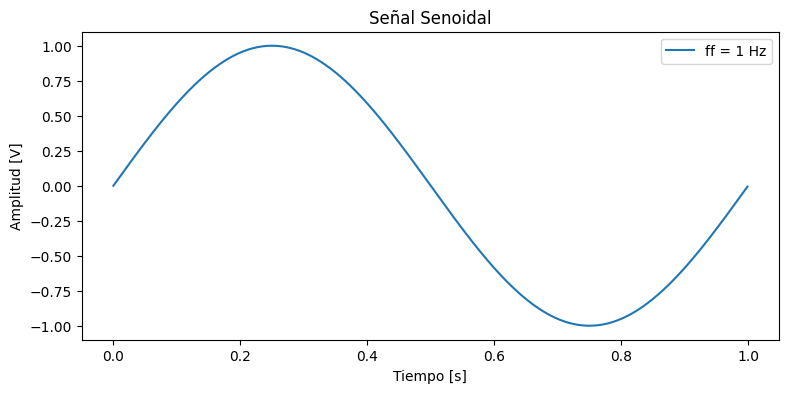

In [3]:
ff = 1 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.show()


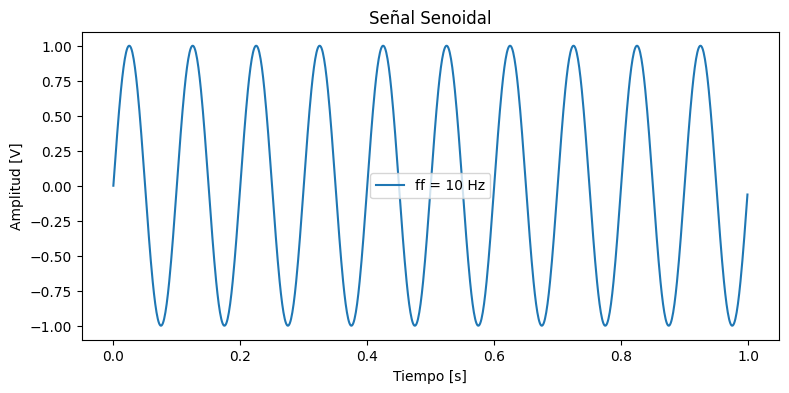

In [4]:
ff = 10 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.show()


Para ambos se observa la señal senoidal muestreada ya que en ambos casos $f_f << f_N$

#### Primer Caso  $f_f = 500\ Hz$

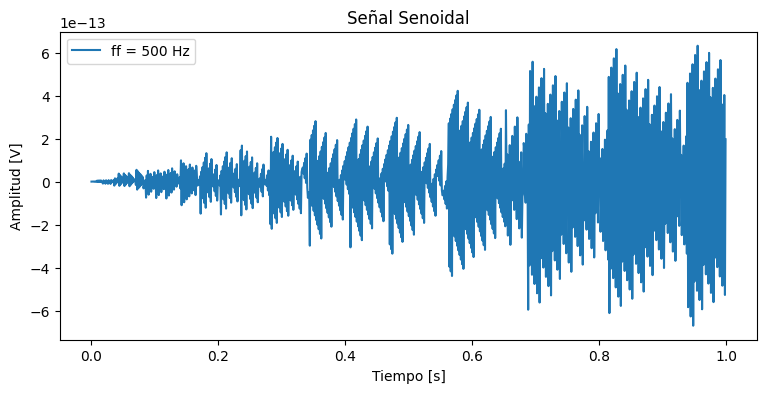

In [4]:
ff = 500 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.show()

Para $f_f = 500\ Hz$ (frecuencia de Nyquist) lo que deberiamos ver en realidad es una linea recta constante en cero ya que mi $ \phi = 0$ la señal quedaria $x[n] = sin(2\pi \cdot 500\cdot \frac{n}{1000}) = sin(\pi \cdot n) $ por ende todas mis muestras caerían en cero haciendole parecer al sistema digital que la señal no existe.
Aunque lo que estamos viendo es algo completamente distinto. Esto en realidad es un error de redondeo que se va acumulando y ampliando ya que python no calcula $\pi$ con infinitos decimales. Para arreglarlo debo ajustar manualemnte la escala $y$ (amplitud).


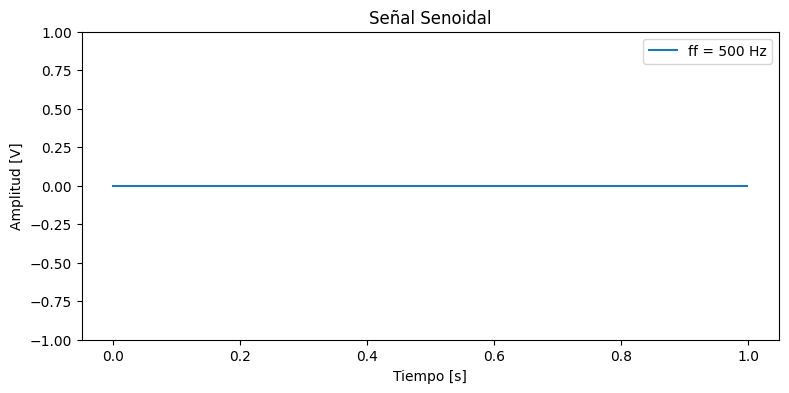

In [5]:
ff = 500 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.ylim(-1, 1)#Ajuste
plt.legend()
plt.show()

Ahora si se puede ver perfectamente lo que pasaria cuando $f_f = f_N$


#### Segundo Caso $f_f = 999\ Hz$

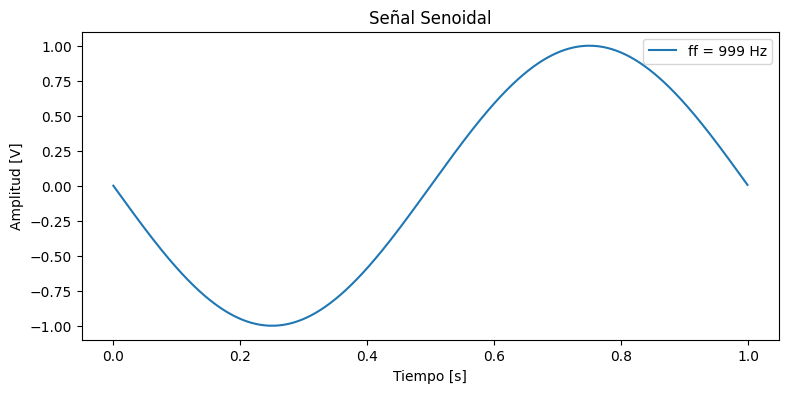

In [6]:
ff = 999 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.show()

Para este grafico se puedee ver como a $f_f > f_N$ se "pierde" la señal original. En realidad lo que esta pasando es un solapamiento espectral o **Aliasing**; osea que la frecuencia que estoy viendo sigue la esta ecuacion:
$$ f_{alias} = |f_f - k \cdot f_s| $$

Donde $k = \frac {f_f}{f_s}$, es el número de vultas completas que la señal alcanza a dar entre cada mumestras.

Entonces para este caso $f_{alias} = |-1|\ Hz$, osea la señal se va a ver igual al caso base desfasada $\pi$

#### Tercer Caso $f_f = 1001\ Hz$

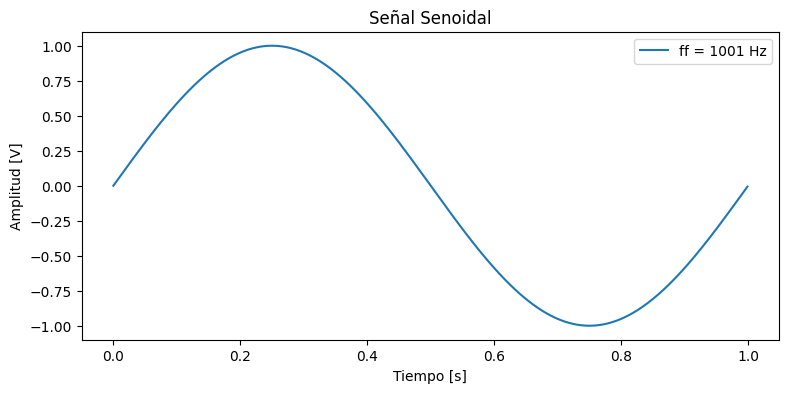

In [7]:
ff = 1001 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.show()

Para el tercer caso tambien se genera un solapamiento espectral $f_{alias} = 1\ Hz$ mostrando una señal igual al caso base.

#### Cuarto Caso $f_f = 2001\ Hz$

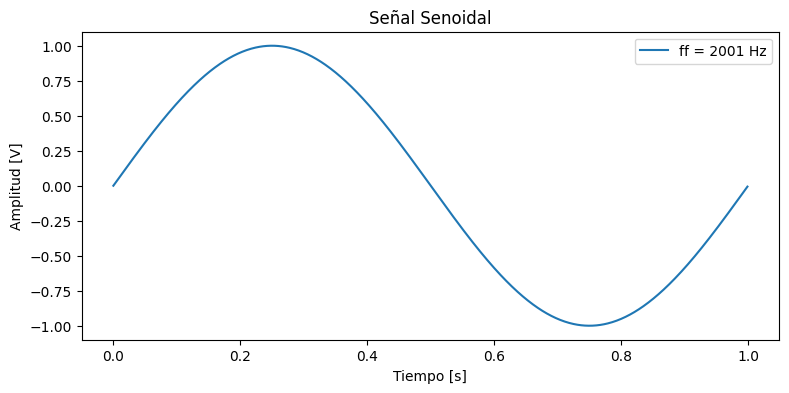

In [8]:
ff = 2001 # Frecuencia de la señal

#Invoco funcion
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

#Grafico
plt.figure(figsize=(9, 4))
plt.plot(tt, xx, label=f'ff = {ff} Hz') 
plt.title('Señal Senoidal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend()
plt.show()

Para el ultimo caso se ve lo mismo que el caso base ya que $k=2$ por ende $f_{alias} = |2001 - 2 \cdot 1000| = 1\ Hz$

# Conclusion


Mediante este trabajo se pudieron abordar varios temas vistos en la materia, principalemnte la importancia del **Teroma de Nyquist** al momento de digitalizasar(o discretizar) una señal continua y las consecuencias que tiene el solapamiento espectral (**Aliasing**). A su vez se introdujo como area de trabajo el entorno **Jupyter** permitiendo elaborar informes de forma practica y prolija para los temas que abarcará la meteria. 